<a href="https://colab.research.google.com/github/ghafirahyutiana/240441100101_GhafirahYutiana_Tugas2_DL/blob/main/240441100101_Ghafirah_Yutiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Implementasi CNN — Fashion-MNIST
**Bagian B — Perbandingan CNN Sederhana (Model A) vs CNN Residual (Model B)**

Notebook ini reproducible: tinggal Run All. Framework: **PyTorch**.

Isi notebook:
1. B.1 — Dataset & Setup (Fashion-MNIST)
2. B.2 — Implementasi Model A (CNN sederhana) & Model B (CNN + residual connection)
3. B.3 — Eksperimen & Evaluasi (loss/accuracy curve, akurasi test, jumlah parameter, waktu training, confusion matrix)


In [ ]:
# Jika di Google Colab / environment baru, jalankan cell ini dulu
# !pip install torch torchvision matplotlib scikit-learn seaborn -q


## 0. Import Library & Setup Reproducibility

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import time
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Menggunakan device:", device)


Menggunakan device: cpu


## B.1 — Dataset dan Setup

Dataset yang digunakan: **Fashion-MNIST** (28x28 grayscale, 10 kelas item fashion: T-shirt/top, Trouser,
Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).

Dipilih karena ringan secara komputasi (ukuran kecil, 1 channel) sehingga training dua model bisa
dilakukan dengan cepat, namun tetap cukup menantang untuk membandingkan performa arsitektur.


In [ ]:
BATCH_SIZE = 64

# Normalisasi standar untuk Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Split train -> train/validation (90/10)
val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Jumlah data train: {len(train_dataset)}")
print(f"Jumlah data validation: {len(val_dataset)}")
print(f"Jumlah data test: {len(test_dataset)}")


100%|██████████| 26.4M/26.4M [00:01<00:00, 21.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 354kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.3MB/s]


Jumlah data train: 54000
Jumlah data validation: 6000
Jumlah data test: 10000


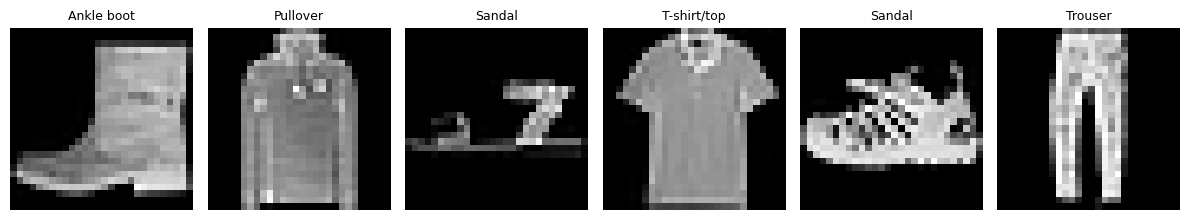

In [ ]:
# Preview beberapa sample data
fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
for i in range(6):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(class_names[label], fontsize=9)
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## B.2 — Implementasi Model

### Model A — CNN Sederhana (custom)
3 blok Conv-ReLU-Pooling, diikuti fully connected layer + output softmax (lewat CrossEntropyLoss).

### Model B — CNN dengan Residual Connection
3 residual block sederhana (bukan pretrained), masing-masing terdiri dari 2 conv + batch norm dengan
skip connection (identity/projection shortcut), mirip prinsip dasar ResNet tapi disederhanakan.

Kedua model dilatih dengan hyperparameter identik (epoch, batch size, optimizer, learning rate) agar
perbandingan adil.


In [ ]:
class ModelA(nn.Module):
    """CNN sederhana: 3 blok Conv-ReLU-Pooling + FC + output softmax."""
    def __init__(self, num_classes=10):
        super(ModelA, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 28x28 -> 14x14
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 14x14 -> 7x7
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 7x7 -> 3x3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
            # Softmax tidak eksplisit karena sudah ditangani oleh nn.CrossEntropyLoss
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


In [ ]:
class ResidualBlock(nn.Module):
    """Residual block sederhana: Conv-BN-ReLU-Conv-BN + skip connection, lalu ReLU."""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Projection shortcut jika dimensi berubah (channel atau stride berbeda)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity   # skip connection
        out = self.relu(out)
        return out


class ModelB(nn.Module):
    """CNN dengan 3 residual block sederhana (bukan ResNet pretrained)."""
    def __init__(self, num_classes=10):
        super(ModelB, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.res_block1 = ResidualBlock(16, 16, stride=1)        # 28x28
        self.res_block2 = ResidualBlock(16, 32, stride=2)        # 28x28 -> 14x14
        self.res_block3 = ResidualBlock(32, 64, stride=2)        # 14x14 -> 7x7

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_a_tmp = ModelA()
model_b_tmp = ModelB()
print("Jumlah parameter Model A:", count_parameters(model_a_tmp))
print("Jumlah parameter Model B:", count_parameters(model_b_tmp))

# Cek arsitektur lengkap
print("\n--- Model A ---")
print(model_a_tmp)
print("\n--- Model B ---")
print(model_b_tmp)


Jumlah parameter Model A: 98442
Jumlah parameter Model B: 77754

--- Model A ---
ModelA(
  (block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)



## B.3 — Eksperimen dan Evaluasi

Fungsi training generik dipakai untuk kedua model dengan hyperparameter yang identik:
- Epoch: 15
- Batch size: 64
- Optimizer: Adam
- Learning rate: 0.001


In [ ]:
EPOCHS = 15
LEARNING_RATE = 0.001

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    start_time = time.time()

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- Validation ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time
    print(f"\nWaktu training total: {total_time:.2f} detik ({total_time/60:.2f} menit)")

    return model, history, total_time


In [ ]:
print("=== Training Model A (CNN Sederhana) ===\n")
model_a = ModelA()
model_a, history_a, time_a = train_model(model_a, train_loader, val_loader)


=== Training Model A (CNN Sederhana) ===

Epoch [1/15] Train Loss: 0.5916, Train Acc: 0.7857 | Val Loss: 0.3733, Val Acc: 0.8610
Epoch [2/15] Train Loss: 0.3616, Train Acc: 0.8690 | Val Loss: 0.3160, Val Acc: 0.8817
Epoch [3/15] Train Loss: 0.3089, Train Acc: 0.8879 | Val Loss: 0.2967, Val Acc: 0.8900
Epoch [4/15] Train Loss: 0.2784, Train Acc: 0.8995 | Val Loss: 0.2771, Val Acc: 0.8955
Epoch [5/15] Train Loss: 0.2579, Train Acc: 0.9060 | Val Loss: 0.2615, Val Acc: 0.9000
Epoch [6/15] Train Loss: 0.2387, Train Acc: 0.9126 | Val Loss: 0.2480, Val Acc: 0.9093
Epoch [7/15] Train Loss: 0.2230, Train Acc: 0.9179 | Val Loss: 0.2478, Val Acc: 0.9077
Epoch [8/15] Train Loss: 0.2099, Train Acc: 0.9225 | Val Loss: 0.2506, Val Acc: 0.9107
Epoch [9/15] Train Loss: 0.1989, Train Acc: 0.9272 | Val Loss: 0.2508, Val Acc: 0.9082
Epoch [10/15] Train Loss: 0.1867, Train Acc: 0.9304 | Val Loss: 0.2453, Val Acc: 0.9113
Epoch [11/15] Train Loss: 0.1780, Train Acc: 0.9337 | Val Loss: 0.2527, Val Acc: 0.9132

In [ ]:
print("=== Training Model B (CNN Residual) ===\n")
model_b = ModelB()
model_b, history_b, time_b = train_model(model_b, train_loader, val_loader)


=== Training Model B (CNN Residual) ===

Epoch [1/15] Train Loss: 0.6183, Train Acc: 0.7883 | Val Loss: 0.4274, Val Acc: 0.8512
Epoch [2/15] Train Loss: 0.3697, Train Acc: 0.8687 | Val Loss: 0.2980, Val Acc: 0.8917
Epoch [3/15] Train Loss: 0.3155, Train Acc: 0.8880 | Val Loss: 0.3055, Val Acc: 0.8873
Epoch [4/15] Train Loss: 0.2809, Train Acc: 0.9008 | Val Loss: 0.2743, Val Acc: 0.8963
Epoch [5/15] Train Loss: 0.2589, Train Acc: 0.9087 | Val Loss: 0.2735, Val Acc: 0.9043
Epoch [6/15] Train Loss: 0.2425, Train Acc: 0.9142 | Val Loss: 0.2424, Val Acc: 0.9138
Epoch [7/15] Train Loss: 0.2236, Train Acc: 0.9200 | Val Loss: 0.2464, Val Acc: 0.9137
Epoch [8/15] Train Loss: 0.2122, Train Acc: 0.9242 | Val Loss: 0.2310, Val Acc: 0.9153
Epoch [9/15] Train Loss: 0.2003, Train Acc: 0.9288 | Val Loss: 0.2388, Val Acc: 0.9128
Epoch [10/15] Train Loss: 0.1913, Train Acc: 0.9313 | Val Loss: 0.2237, Val Acc: 0.9223
Epoch [11/15] Train Loss: 0.1829, Train Acc: 0.9349 | Val Loss: 0.2188, Val Acc: 0.9218


### Jalankan Ulang Pelatihan Model (jika `history_a` atau `history_b` tidak terdefinisi)

Jika Anda mendapatkan `NameError` untuk `history_a` atau `history_b`, kemungkinan state kernel telah hilang atau cell pelatihan belum dijalankan. Cell berikut akan menjalankan ulang proses pelatihan untuk Model A dan Model B untuk memastikan variabel `history_a` dan `history_b` tersedia untuk plotting.

In [ ]:
print("=== Melatih ulang Model A (CNN Sederhana) ===\n")
model_a = ModelA()
model_a, history_a, time_a = train_model(model_a, train_loader, val_loader)

=== Melatih ulang Model A (CNN Sederhana) ===

Epoch [1/15] Train Loss: 0.5658, Train Acc: 0.7922 | Val Loss: 0.3519, Val Acc: 0.8700
Epoch [2/15] Train Loss: 0.3426, Train Acc: 0.8774 | Val Loss: 0.2952, Val Acc: 0.8928
Epoch [3/15] Train Loss: 0.2931, Train Acc: 0.8941 | Val Loss: 0.2939, Val Acc: 0.8967
Epoch [4/15] Train Loss: 0.2672, Train Acc: 0.9022 | Val Loss: 0.2697, Val Acc: 0.8982
Epoch [5/15] Train Loss: 0.2417, Train Acc: 0.9112 | Val Loss: 0.2728, Val Acc: 0.9002
Epoch [6/15] Train Loss: 0.2266, Train Acc: 0.9170 | Val Loss: 0.2480, Val Acc: 0.9112
Epoch [7/15] Train Loss: 0.2117, Train Acc: 0.9217 | Val Loss: 0.2405, Val Acc: 0.9108
Epoch [8/15] Train Loss: 0.2003, Train Acc: 0.9266 | Val Loss: 0.2315, Val Acc: 0.9163
Epoch [9/15] Train Loss: 0.1870, Train Acc: 0.9306 | Val Loss: 0.2478, Val Acc: 0.9148
Epoch [10/15] Train Loss: 0.1744, Train Acc: 0.9343 | Val Loss: 0.2554, Val Acc: 0.9158
Epoch [11/15] Train Loss: 0.1652, Train Acc: 0.9382 | Val Loss: 0.2379, Val Acc: 0

In [ ]:
print("=== Melatih ulang Model B (CNN Residual) ===\n")
model_b = ModelB()
model_b, history_b, time_b = train_model(model_b, train_loader, val_loader)

=== Melatih ulang Model B (CNN Residual) ===

Epoch [1/15] Train Loss: 0.6212, Train Acc: 0.7874 | Val Loss: 0.3904, Val Acc: 0.8588
Epoch [2/15] Train Loss: 0.3729, Train Acc: 0.8680 | Val Loss: 0.3150, Val Acc: 0.8852
Epoch [3/15] Train Loss: 0.3181, Train Acc: 0.8879 | Val Loss: 0.2955, Val Acc: 0.8913
Epoch [4/15] Train Loss: 0.2847, Train Acc: 0.8988 | Val Loss: 0.2775, Val Acc: 0.9008
Epoch [5/15] Train Loss: 0.2596, Train Acc: 0.9069 | Val Loss: 0.2714, Val Acc: 0.9018
Epoch [6/15] Train Loss: 0.2452, Train Acc: 0.9127 | Val Loss: 0.2364, Val Acc: 0.9142
Epoch [7/15] Train Loss: 0.2301, Train Acc: 0.9170 | Val Loss: 0.2509, Val Acc: 0.9087
Epoch [8/15] Train Loss: 0.2155, Train Acc: 0.9223 | Val Loss: 0.2280, Val Acc: 0.9137
Epoch [9/15] Train Loss: 0.2049, Train Acc: 0.9264 | Val Loss: 0.2266, Val Acc: 0.9195
Epoch [10/15] Train Loss: 0.1962, Train Acc: 0.9287 | Val Loss: 0.2203, Val Acc: 0.9190
Epoch [11/15] Train Loss: 0.1867, Train Acc: 0.9340 | Val Loss: 0.2264, Val Acc: 0.

### Kurva Training vs Validation Loss per Epoch

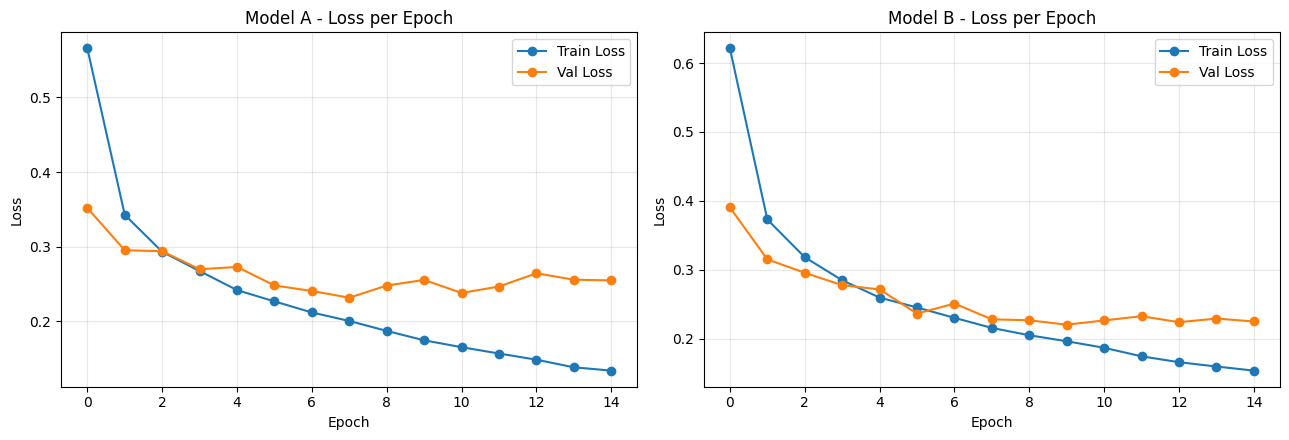

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_a["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history_a["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Model A - Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_b["train_loss"], label="Train Loss", marker="o")
axes[1].plot(history_b["val_loss"], label="Val Loss", marker="o")
axes[1].set_title("Model B - Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Kurva Training vs Validation Accuracy per Epoch

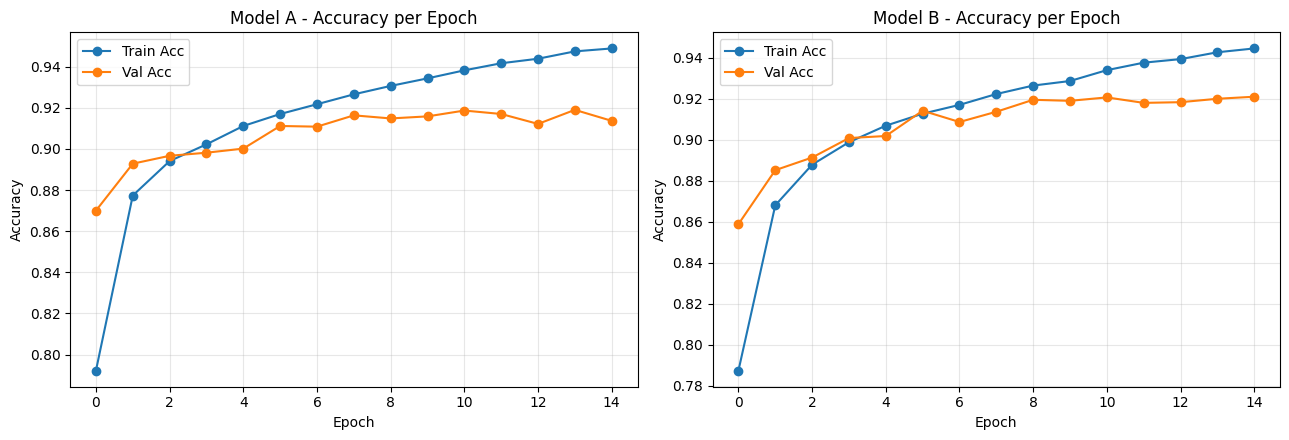

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_a["train_acc"], label="Train Acc", marker="o")
axes[0].plot(history_a["val_acc"], label="Val Acc", marker="o")
axes[0].set_title("Model A - Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_b["train_acc"], label="Train Acc", marker="o")
axes[1].plot(history_b["val_acc"], label="Val Acc", marker="o")
axes[1].set_title("Model B - Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Evaluasi pada Test Set (Akurasi Akhir & Confusion Matrix)

In [ ]:
def evaluate_on_test(model, test_loader, device=device):
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    return test_acc, np.array(all_labels), np.array(all_preds)

test_acc_a, y_true_a, y_pred_a = evaluate_on_test(model_a, test_loader)
test_acc_b, y_true_b, y_pred_b = evaluate_on_test(model_b, test_loader)

print(f"Akurasi Model A pada test set: {test_acc_a:.4f}")
print(f"Akurasi Model B pada test set: {test_acc_b:.4f}")


Akurasi Model A pada test set: 0.9110
Akurasi Model B pada test set: 0.9153


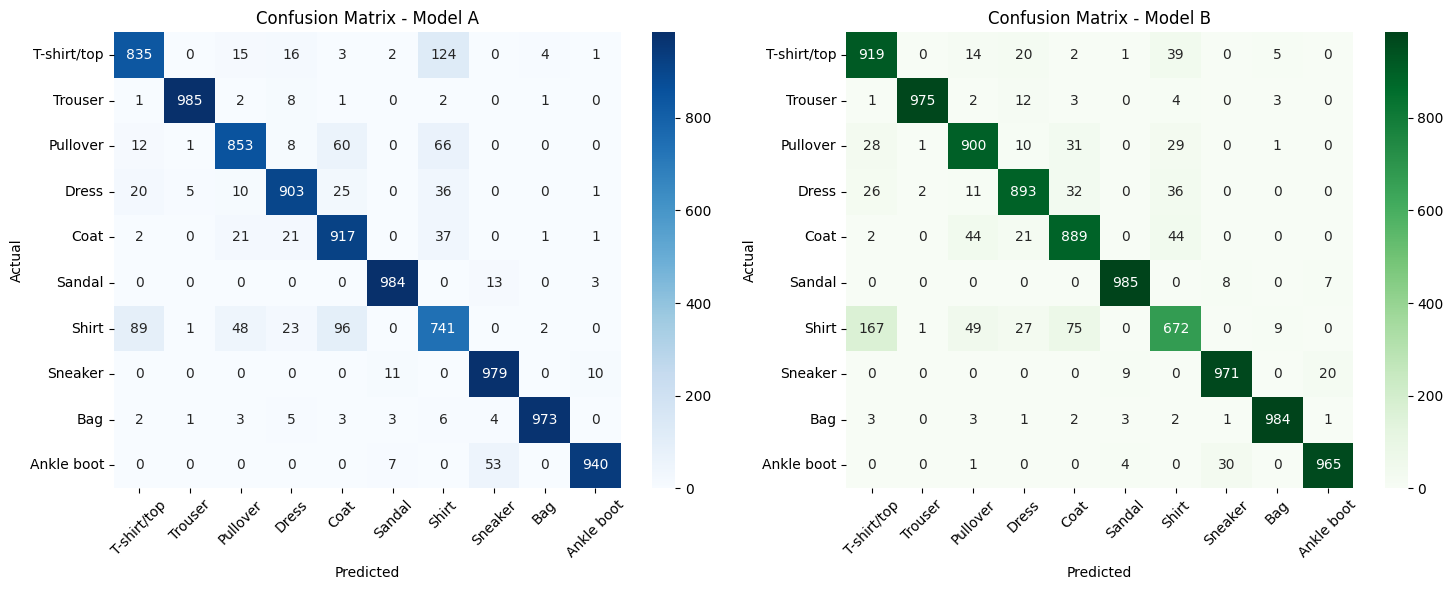

In [ ]:
cm_a = confusion_matrix(y_true_a, y_pred_a)
cm_b = confusion_matrix(y_true_b, y_pred_b)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_a, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix - Model A")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_b, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix - Model B")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
print("Classification Report - Model A")
print(classification_report(y_true_a, y_pred_a, target_names=class_names))

print("\nClassification Report - Model B")
print(classification_report(y_true_b, y_pred_b, target_names=class_names))


Classification Report - Model A
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.83      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.85      0.87      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.83      0.92      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.73      0.74      0.74      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Classification Report - Model B
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.92      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover 

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Metode": ["Model A (CNN Sederhana)", "Model B (CNN Residual)"],
    "Jumlah Parameter": [count_parameters(model_a), count_parameters(model_b)],
    "Akurasi Test": [f"{test_acc_a:.4f}", f"{test_acc_b:.4f}"],
    "Waktu Training (detik)": [f"{time_a:.2f}", f"{time_b:.2f}"],
    "Final Train Loss": [f"{history_a['train_loss'][-1]:.4f}", f"{history_b['train_loss'][-1]:.4f}"],
    "Final Val Loss": [f"{history_a['val_loss'][-1]:.4f}", f"{history_b['val_loss'][-1]:.4f}"],
})

summary


,Metode,Jumlah Parameter,Akurasi Test,Waktu Training (detik),Final Train Loss,Final Val Loss
0,Model A (CNN Sederhana),98442,0.9110,742.15,0.1338,0.2547
1,Model B (CNN Residual),77754,0.9153,2332.53,0.1535,0.2249


## Kesimpulan (isi otomatis, silakan sesuaikan narasi setelah menjalankan notebook)

Bandingkan hasil dari tabel ringkasan di atas untuk menjawab:
- Model mana yang punya akurasi test lebih tinggi?
- Apakah Model B (residual) konvergen lebih stabil / lebih cepat dibanding Model A?
- Trade-off antara jumlah parameter, waktu training, dan akurasi.
- Kelas mana yang paling sering tertukar (lihat confusion matrix), misalnya antara *Shirt*, *T-shirt/top*,
  dan *Pullover* yang secara visual mirip.
